In [ ]:
import pandas as pd
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
import umap
import spacy
import numpy as np
import evaluate


In [2]:
df = pd.read_csv('C:\\Users\\marga\\Desktop\\AIEngineering_BBDA\\Hotel-Reviews-Sentiment-Analysis-NLP-Project\\data\\booking_reviews_cleaned.csv')

In [3]:
df.head(1)

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,trip_type,traveller_type,stay_length
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,Business trip,Solo traveller,Stayed 1 night


# using a pre-built sentiment analysis model from Hugging Face (generic)

In [4]:
classifier = pipeline('sentiment-analysis')


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [6]:
# testing on sample lines of the df:

sample_reviews = df['review_text'].sample(5).tolist()

classifier(sample_reviews)

[{'label': 'NEGATIVE', 'score': 0.9621061086654663},
 {'label': 'POSITIVE', 'score': 0.9994972944259644},
 {'label': 'NEGATIVE', 'score': 0.9465890526771545},
 {'label': 'POSITIVE', 'score': 0.9998795986175537},
 {'label': 'POSITIVE', 'score': 0.9980931878089905}]

In [9]:
# for all reviews, with batches, porogress bar and saving results in new columns in df: 

from tqdm.auto import tqdm

texts = df["review_text"].fillna("").astype(str).tolist()

all_results = []

batch_size = 16

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i + batch_size]
    
    batch_results = classifier(
        batch,
        truncation=True
    )
    
    all_results.extend(batch_results)

df["transformer_label"] = [result["label"] for result in all_results]
df["transformer_score"] = [result["score"] for result in all_results]

df[["review_text", "rating", "transformer_label", "transformer_score"]].head()

  0%|          | 0/1629 [00:00<?, ?it/s]

,review_text,rating,transformer_label,transformer_score
0,"Everything was perfect! Quite, cozy place to r...",10.0,POSITIVE,0.999868
1,Very friendly host and perfect breakfast!,9.0,POSITIVE,0.999887
2,It was just what we wanted for a week by the b...,10.0,POSITIVE,0.839765
3,My stay in the house was a experiencing bliss ...,10.0,POSITIVE,0.999888
4,The building itself has a very musty smell in ...,9.2,NEGATIVE,0.779410


In [10]:
print("Review text:")
print(df.loc[4, "review_text"])

print("\nRating:")
print(df.loc[4, "rating"])

print("\nTransformer prediction:")
print(df.loc[4, "transformer_label"])

print("\nTransformer confidence:")
print(df.loc[4, "transformer_score"])

Review text:
The building itself has a very musty smell in the hallway (despite being built in 1988), but the apartment itself smells good, which makes it bearable. 
When showering, the hot water goes off every 2-3 minutes for about 20-30 seconds and then only cold water comes out. The hot water then comes back again. This should be checked out. That is the only thing we didn’t like about the apartment. ,

The view was great, the apartment furnished in a modern style and equipped with everything you may need. The apartment was clean. 
There is free, secure parking outside in the building’s parking lot or downstairs in the garage. 
Jan always responded promptly to all messages sent via Booking.com messenger.

Rating:
9.2

Transformer prediction:
NEGATIVE

Transformer confidence:
0.7794097661972046


In [11]:
# Although the review has a high rating, the pretrained transformer classified it as negative because the text contains a complaint about a musty smell. 
# This shows that text-based sentiment can capture specific negative aspects even inside generally positive reviews.

In [13]:
def rating_to_binary_sentiment(rating):
    if rating >= 8:
        return "POSITIVE"
    else:
        return "NEGATIVE"

df["rating_sentiment_binary"] = df["rating"].apply(rating_to_binary_sentiment)

df[["rating", "rating_sentiment_binary", "transformer_label", "transformer_score"]].head(10)

,rating,rating_sentiment_binary,transformer_label,transformer_score
0,10.0,POSITIVE,POSITIVE,0.999868
1,9.0,POSITIVE,POSITIVE,0.999887
2,10.0,POSITIVE,POSITIVE,0.839765
3,10.0,POSITIVE,POSITIVE,0.999888
4,9.2,POSITIVE,NEGATIVE,0.779410
5,10.0,POSITIVE,POSITIVE,0.999774
6,10.0,POSITIVE,POSITIVE,0.999398
7,8.3,POSITIVE,POSITIVE,0.995852
8,9.2,POSITIVE,NEGATIVE,0.998240
9,10.0,POSITIVE,POSITIVE,0.999866


In [14]:
df["rating_sentiment_binary"].value_counts()

rating_sentiment_binary
POSITIVE    19147
NEGATIVE     6909
Name: count, dtype: int64

In [15]:
df["transformer_label"].value_counts()

transformer_label
POSITIVE    13381
NEGATIVE    12675
Name: count, dtype: int64

In [17]:
# classification report:

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    df["rating_sentiment_binary"],
    df["transformer_label"]
))

              precision    recall  f1-score   support

    NEGATIVE       0.38      0.70      0.49      6909
    POSITIVE       0.84      0.59      0.69     19147

    accuracy                           0.62     26056
   macro avg       0.61      0.64      0.59     26056
weighted avg       0.72      0.62      0.64     26056



In [25]:
# The pretrained transformer achieved **62% agreement** with the rating-based sentiment labels. 
# It performs better on the **POSITIVE** class, with high precision (**0.84**), meaning that when it predicts a review as positive, 
# it usually matches the rating-based label. However, the **NEGATIVE** precision is low (**0.38**), 
# which means many reviews predicted as negative actually have high ratings. 

# This may happen because hotel reviews often contain mixed feedback: 
# a guest can give a high score overall while still mentioning negative details such as smell, noise, cleanliness, or breakfast issues.
#  Therefore, the disagreement between rating-based sentiment and transformer sentiment is useful, because it can reveal hidden complaints inside otherwise positive reviews.
 
#  This pretrained transformer is a good first baseline, but the next step should be comparing it with classical ML models and later fine-tuning a transformer on this specific dataset.

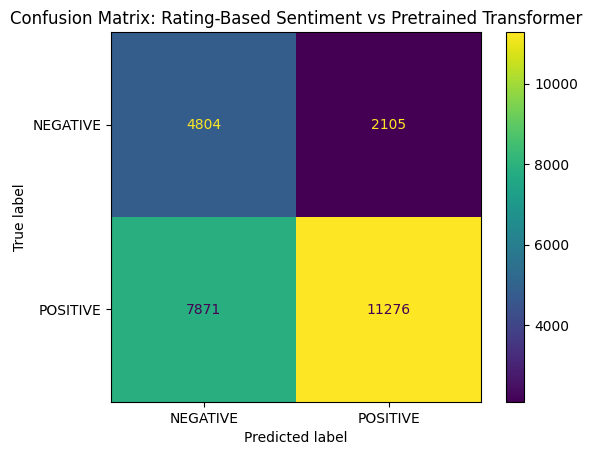

In [18]:
# Confusion matrix:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["NEGATIVE", "POSITIVE"]

cm = confusion_matrix(
    df["rating_sentiment_binary"],
    df["transformer_label"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Confusion Matrix: Rating-Based Sentiment vs Pretrained Transformer")
plt.show()



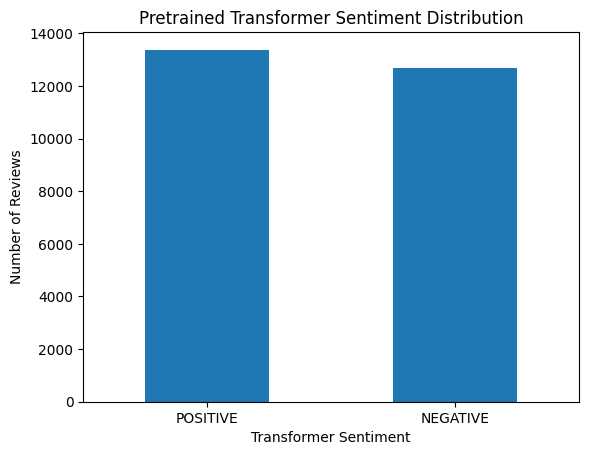

In [19]:
df["transformer_label"].value_counts().plot(kind="bar")

plt.title("Pretrained Transformer Sentiment Distribution")
plt.xlabel("Transformer Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

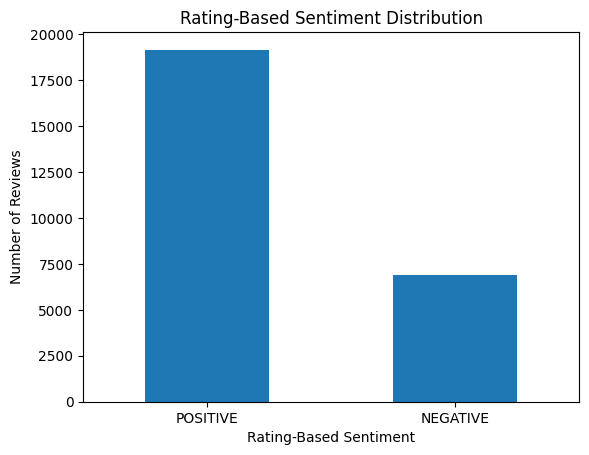

In [20]:
df["rating_sentiment_binary"].value_counts().plot(kind="bar")

plt.title("Rating-Based Sentiment Distribution")
plt.xlabel("Rating-Based Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

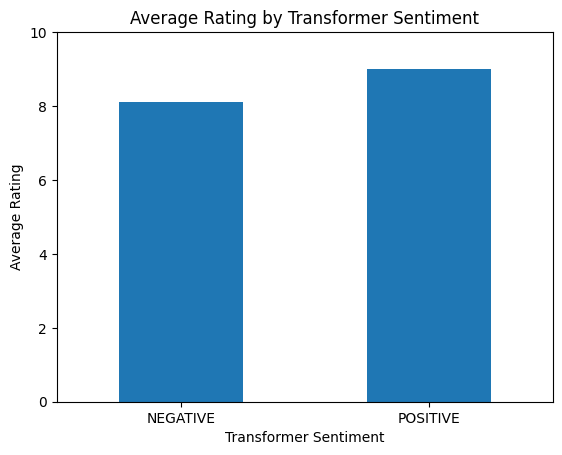

In [21]:
avg_rating_by_transformer = df.groupby("transformer_label")["rating"].mean()

avg_rating_by_transformer.plot(kind="bar")

plt.title("Average Rating by Transformer Sentiment")
plt.xlabel("Transformer Sentiment")
plt.ylabel("Average Rating")
plt.ylim(0, 10)
plt.xticks(rotation=0)
plt.show()

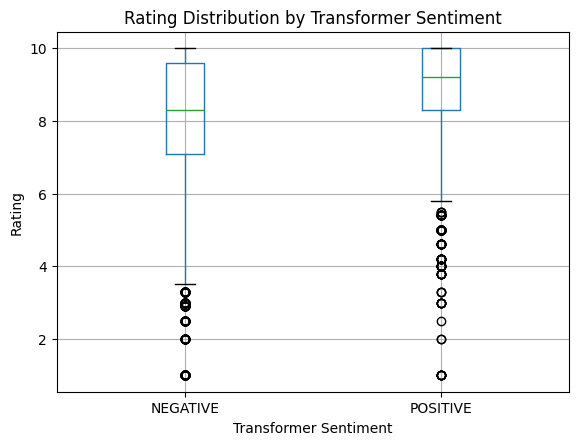

In [22]:
df.boxplot(column="rating", by="transformer_label")

plt.title("Rating Distribution by Transformer Sentiment")
plt.suptitle("")
plt.xlabel("Transformer Sentiment")
plt.ylabel("Rating")
plt.show()

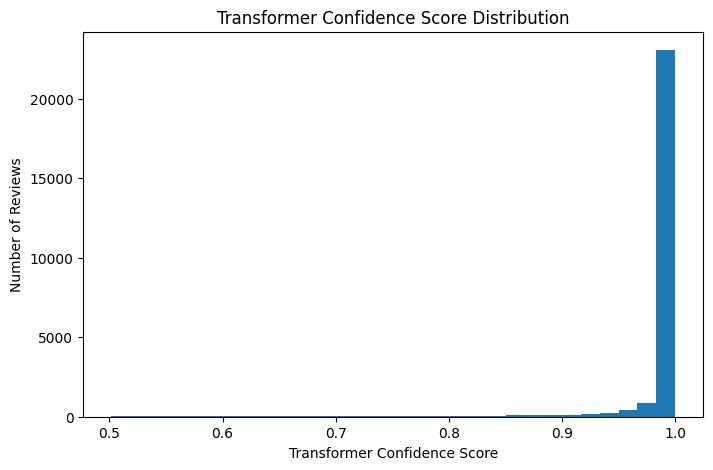

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["transformer_score"], bins=30)

plt.title("Transformer Confidence Score Distribution")
plt.xlabel("Transformer Confidence Score")
plt.ylabel("Number of Reviews")
plt.show()

# Using specifc Pre-Trained Transformer:

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

star_classifier = pipeline("sentiment-analysis",model=model,tokenizer=tokenizer)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [28]:
# this model is better, so we get more ratings, not just positive-negative

In [27]:
star_classifier(df["review_text"].iloc[0], truncation=True)

[{'label': '5 stars', 'score': 0.7167595028877258}]

In [29]:
sample_texts = df["review_text"].head(10).tolist()

star_classifier(sample_texts, truncation=True)

[{'label': '5 stars', 'score': 0.7167595028877258},
 {'label': '5 stars', 'score': 0.8368703126907349},
 {'label': '5 stars', 'score': 0.6667758226394653},
 {'label': '5 stars', 'score': 0.8031072020530701},
 {'label': '3 stars', 'score': 0.3947681784629822},
 {'label': '5 stars', 'score': 0.9215629696846008},
 {'label': '4 stars', 'score': 0.4999958872795105},
 {'label': '5 stars', 'score': 0.47173967957496643},
 {'label': '1 star', 'score': 0.44656816124916077},
 {'label': '5 stars', 'score': 0.8680040240287781}]

In [ ]:
from tqdm.auto import tqdm

texts = df["review_text"].fillna("").astype(str).tolist()

star_results = []
batch_size = 16

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i + batch_size]
    
    batch_results = star_classifier(
        batch,
        truncation=True
    )
    
    star_results.extend(batch_results)

df["star_transformer_label"] = [r["label"] for r in star_results]
df["star_transformer_score"] = [r["score"] for r in star_results]

df.to_csv("../data/booking_reviews_with_two_transformer_predictions.csv", index=False)

  0%|          | 0/1629 [00:00<?, ?it/s]